# CSI Phase And Trajectory Plots

This notebook reads the NetCDF xarray dataset produced by `processing/extract_csi_from_smb.py` from `data/csi.nc` or the newest timestamped `data/csi_*.nc`, plots CSI phase in degrees for all hostnames versus cycle ID, and plots the rover trajectory in 2D.


In [34]:
# Install pip packages in the current Jupyter kernel when needed.
import sys

!{sys.executable} -m pip install numpy matplotlib xarray requests pyyaml scipy pillow



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
from datetime import datetime
from pathlib import Path
import re

import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter, FuncAnimation, PillowWriter
from matplotlib.colors import Normalize
import numpy as np
import requests
import xarray as xr
import yaml

POSITIONS_URL = (
    'https://raw.githubusercontent.com/techtile-by-dramco/'
    'techtile-description/refs/heads/main/geometry/'
    'techtile_antenna_locations.yml'
)

plt.style.use('seaborn-v0_8-whitegrid')

experiment_id = "EXP003"
dataset_pattern = re.compile(
    rf"^csi_{re.escape(experiment_id)}_(?P<timestamp>\d{{8}}_\d{{6}})(?:_\d{{2}})?\.nc$"
)
dataset_search_dirs = [Path.cwd(), Path.cwd() / "processing"]
HEATMAP_MAX_CYCLE_VALUES = 100


def dataset_sort_key(path):
    match = dataset_pattern.match(path.name)
    if match is not None:
        dataset_time = datetime.strptime(match.group("timestamp"), "%Y%m%d_%H%M%S")
    else:
        dataset_time = datetime.fromtimestamp(path.stat().st_mtime)
    return dataset_time, path.stat().st_mtime, path.name


candidate_paths = []
seen_paths = set()
for search_dir in dataset_search_dirs:
    for candidate in search_dir.glob(f"csi_{experiment_id}*.nc"):
        resolved_candidate = candidate.resolve()
        if resolved_candidate in seen_paths:
            continue
        candidate_paths.append(resolved_candidate)
        seen_paths.add(resolved_candidate)

candidate_paths.sort(key=dataset_sort_key, reverse=True)

if not candidate_paths:
    searched_locations = ", ".join(str(path.resolve()) for path in dataset_search_dirs)
    raise FileNotFoundError(
        f"Could not find a dataset matching csi_{experiment_id}*.nc in: {searched_locations}"
    )

DATASET_PATH = candidate_paths[0]

ds = xr.open_dataset(DATASET_PATH)
print(f'Loaded dataset: {DATASET_PATH}')
print(ds)


def load_antenna_positions(positions_url=POSITIONS_URL):
    response = requests.get(positions_url, timeout=20)
    response.raise_for_status()
    config = yaml.safe_load(response.text)
    positions = {}
    for entry in config['antennes']:
        tile = str(entry['tile']).upper()
        # Mirror compute-tx-weights-sionna.py and use channels[1].
        channel = entry['channels'][1]
        positions[tile] = np.array([channel['x'], channel['y'], channel['z']], dtype=float)
    return positions


try:
    antenna_positions = load_antenna_positions()
    print(f'Loaded antenna positions from: {POSITIONS_URL}')
    print(f'Mapped {len(antenna_positions)} tile positions')
    missing_positions = sorted(
        hostname
        for hostname in ds['hostname'].values.astype(str)
        if hostname.upper() not in antenna_positions
    )
    if missing_positions:
        print('Hostnames without antenna position mapping:', missing_positions)
except Exception as exc:
    antenna_positions = {}
    print(f'Warning: failed to load antenna positions from {POSITIONS_URL}: {exc}')

Loaded dataset: C:\Users\Calle\OneDrive\Documenten\GitHub\ELLIIIT-dataset-26\processing\csi_EXP003__EXP005__EXP006.nc
<xarray.Dataset> Size: 2MB
Dimensions:             (cycle_id: 777, hostname: 42, experiment_id: 3)
Coordinates:
  * cycle_id            (cycle_id) int32 3kB 1 2 3 4 5 6 ... 773 774 775 776 777
  * hostname            (hostname) object 336B 'A05' 'A06' 'A07' ... 'G09' 'G10'
  * experiment_id       (experiment_id) object 24B 'EXP003' 'EXP005' 'EXP006'
Data variables:
    csi_real            (experiment_id, cycle_id, hostname) float64 783kB ...
    csi_imag            (experiment_id, cycle_id, hostname) float64 783kB ...
    csi_available       (experiment_id, cycle_id, hostname) float32 392kB ...
    rover_x             (experiment_id, cycle_id) float64 19kB ...
    rover_y             (experiment_id, cycle_id) float64 19kB ...
    rover_z             (experiment_id, cycle_id) float64 19kB ...
    position_available  (experiment_id, cycle_id) float32 9kB ...
Attributes: (

In [36]:
def tick_positions(values, max_ticks=20):
    values = np.asarray(values)
    if values.size <= max_ticks:
        return np.arange(values.size)
    return np.linspace(0, values.size - 1, max_ticks, dtype=int)


def hostname_sort_key(hostname):
    position = antenna_positions.get(str(hostname).upper())
    if position is None:
        return (1, np.inf, np.inf, np.inf, str(hostname))
    x, y, z = [float(value) for value in position]
    return (0, y, x, z, str(hostname))


def ordered_hostnames(hostnames):
    return sorted([str(hostname) for hostname in hostnames], key=hostname_sort_key)


def normalize_experiment_ids(experiment_id):
    if isinstance(experiment_id, str):
        experiment_ids = [experiment_id]
    elif np.isscalar(experiment_id):
        experiment_ids = [str(experiment_id)]
    else:
        experiment_ids = [str(value) for value in experiment_id]
    if not experiment_ids:
        raise ValueError('At least one experiment ID is required.')
    return experiment_ids


def experiment_label(experiment_id):
    return ', '.join(normalize_experiment_ids(experiment_id))


def experiment_phrase(experiment_id):
    experiment_ids = normalize_experiment_ids(experiment_id)
    if len(experiment_ids) == 1:
        return f'experiment {experiment_ids[0]}'
    return f"experiments {', '.join(experiment_ids)}"


def experiment_slug(experiment_id):
    return '_'.join(normalize_experiment_ids(experiment_id))


def normalize_cycle_id_map(experiment_id, cycle_id):
    experiment_ids = normalize_experiment_ids(experiment_id)
    if isinstance(cycle_id, dict):
        cycle_id_map = {}
        for selected_experiment_id in experiment_ids:
            if selected_experiment_id not in cycle_id:
                raise ValueError(
                    f'No cycle ID provided for experiment {selected_experiment_id}.'
                )
            cycle_id_map[selected_experiment_id] = int(cycle_id[selected_experiment_id])
        return cycle_id_map
    if np.isscalar(cycle_id):
        return {selected_experiment_id: int(cycle_id) for selected_experiment_id in experiment_ids}
    cycle_values = list(cycle_id)
    if len(cycle_values) != len(experiment_ids):
        raise ValueError('cycle_id must be a scalar, dict, or list matching the experiment IDs.')
    return {
        selected_experiment_id: int(selected_cycle_id)
        for selected_experiment_id, selected_cycle_id in zip(experiment_ids, cycle_values)
    }


def prepare_heatmap_csi(ds, experiment_id, max_cycle_values=HEATMAP_MAX_CYCLE_VALUES):
    if max_cycle_values is not None:
        max_cycle_values = int(max_cycle_values)
        if max_cycle_values <= 0:
            raise ValueError('max_cycle_values must be positive or None.')

    experiment_ids = normalize_experiment_ids(experiment_id)
    entries = []
    combined_hostnames = []
    seen_hostnames = set()

    for selected_experiment_id in experiment_ids:
        experiment = ds.sel(experiment_id=selected_experiment_id)
        csi_available = experiment['csi_available'].values > 0
        available_host_mask = csi_available.any(axis=0)
        available_cycle_mask = csi_available.any(axis=1)
        present_hostnames = experiment['hostname'].values[available_host_mask].astype(str)
        present_cycle_ids = experiment['cycle_id'].values[available_cycle_mask].astype(int)
        if present_hostnames.size == 0:
            raise ValueError(f'No CSI data available for experiment {selected_experiment_id}.')
        if present_cycle_ids.size == 0:
            raise ValueError(
                f'No CSI cycle IDs available for experiment {selected_experiment_id}.'
            )
        hostnames = ordered_hostnames(present_hostnames)
        csi_complex = experiment['csi_real'] + 1j * experiment['csi_imag']
        csi_complex = csi_complex.sel(hostname=hostnames, cycle_id=present_cycle_ids)
        entries.append(
            {
                'experiment_id': selected_experiment_id,
                'hostnames': hostnames,
                'cycle_ids': present_cycle_ids,
                'csi_complex': csi_complex.transpose('hostname', 'cycle_id').values,
            }
        )
        for hostname in hostnames:
            if hostname not in seen_hostnames:
                seen_hostnames.add(hostname)
                combined_hostnames.append(hostname)

    hostnames = ordered_hostnames(combined_hostnames)
    hostname_to_index = {hostname: index for index, hostname in enumerate(hostnames)}
    total_cycles = sum(entry['cycle_ids'].size for entry in entries)
    csi_complex = np.full((len(hostnames), total_cycles), np.nan + 0j, dtype=np.complex128)
    cycle_labels = []
    group_boundaries = []
    column = 0

    for entry in entries:
        cycle_count = entry['cycle_ids'].size
        row_indices = [hostname_to_index[hostname] for hostname in entry['hostnames']]
        csi_complex[np.ix_(row_indices, np.arange(column, column + cycle_count))] = entry['csi_complex']
        if len(experiment_ids) == 1:
            cycle_labels.extend([str(int(cycle_id)) for cycle_id in entry['cycle_ids']])
        else:
            cycle_labels.extend(
                [f"{entry['experiment_id']}:{int(cycle_id)}" for cycle_id in entry['cycle_ids']]
            )
        group_boundaries.append((entry['experiment_id'], column, column + cycle_count))
        column += cycle_count

    plot_data = {
        'experiment_ids': experiment_ids,
        'hostnames': hostnames,
        'cycle_labels': np.asarray(cycle_labels, dtype=object),
        'csi_complex': csi_complex,
        'group_boundaries': group_boundaries,
        'total_cycle_count': len(cycle_labels),
        'cycle_limit_applied': False,
        'max_cycle_values': max_cycle_values,
    }
    if max_cycle_values is None or len(cycle_labels) <= max_cycle_values:
        return plot_data

    start_column = len(cycle_labels) - max_cycle_values
    trimmed_group_boundaries = []
    for selected_experiment_id, start, end in group_boundaries:
        if end <= start_column:
            continue
        trimmed_group_boundaries.append(
            (
                selected_experiment_id,
                max(0, start - start_column),
                end - start_column,
            )
        )
    plot_data['cycle_labels'] = plot_data['cycle_labels'][start_column:]
    plot_data['csi_complex'] = plot_data['csi_complex'][:, start_column:]
    plot_data['group_boundaries'] = trimmed_group_boundaries
    plot_data['cycle_limit_applied'] = True
    return plot_data


def add_experiment_group_markers(ax, plot_data):
    if len(plot_data['group_boundaries']) <= 1:
        return
    for group_index, (selected_experiment_id, start, end) in enumerate(plot_data['group_boundaries']):
        if group_index > 0:
            ax.axvline(start - 0.5, color='white', linewidth=1.0, alpha=0.9)
        center = (start + end - 1) / 2.0
        ax.text(
            center,
            1.02,
            selected_experiment_id,
            transform=ax.get_xaxis_transform(),
            ha='center',
            va='bottom',
            fontsize=9,
        )


def plot_phase_heatmap(ds, experiment_id, max_cycle_values=HEATMAP_MAX_CYCLE_VALUES):
    plot_data = prepare_heatmap_csi(ds, experiment_id, max_cycle_values=max_cycle_values)
    phase_deg = np.rad2deg(np.angle(plot_data['csi_complex']))
    values = np.ma.masked_invalid(phase_deg)
    cmap = plt.get_cmap('twilight').copy()
    cmap.set_bad(color='lightgray')

    fig_width = max(10, len(plot_data['cycle_labels']) * 0.35)
    fig_height = max(6, len(plot_data['hostnames']) * 0.35)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    image = ax.imshow(
        values,
        aspect='auto',
        interpolation='none',
        cmap=cmap,
        vmin=-180,
        vmax=180,
    )

    x_ticks = tick_positions(plot_data['cycle_labels'])
    y_ticks = np.arange(len(plot_data['hostnames']))
    cycle_axis_label = 'Cycle ID'
    if plot_data['cycle_limit_applied']:
        cycle_axis_label += f" (last {plot_data['max_cycle_values']} values)"
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(plot_data['cycle_labels'][x_ticks], rotation=45, ha='right')
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(plot_data['hostnames'])
    ax.set_xlabel(cycle_axis_label)
    ax.set_ylabel('Hostname')
    ax.set_title(
        f"CSI Phase [deg] for {experiment_phrase(plot_data['experiment_ids'])} "
        '(ordered by antenna position)'
    )
    add_experiment_group_markers(ax, plot_data)

    colorbar = fig.colorbar(image, ax=ax, pad=0.02)
    colorbar.set_label('Phase [deg]')

    fig.tight_layout()
    return fig, ax


def plot_amplitude_heatmap(ds, experiment_id, max_cycle_values=HEATMAP_MAX_CYCLE_VALUES):
    plot_data = prepare_heatmap_csi(ds, experiment_id, max_cycle_values=max_cycle_values)
    amplitude = np.abs(plot_data['csi_complex'])
    values = np.ma.masked_invalid(amplitude)
    cmap = plt.get_cmap('viridis').copy()
    cmap.set_bad(color='lightgray')

    fig_width = max(10, len(plot_data['cycle_labels']) * 0.35)
    fig_height = max(6, len(plot_data['hostnames']) * 0.35)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    image = ax.imshow(
        values,
        aspect='auto',
        interpolation='none',
        cmap=cmap,
    )

    x_ticks = tick_positions(plot_data['cycle_labels'])
    y_ticks = np.arange(len(plot_data['hostnames']))
    cycle_axis_label = 'Cycle ID'
    if plot_data['cycle_limit_applied']:
        cycle_axis_label += f" (last {plot_data['max_cycle_values']} values)"
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(plot_data['cycle_labels'][x_ticks], rotation=45, ha='right')
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(plot_data['hostnames'])
    ax.set_xlabel(cycle_axis_label)
    ax.set_ylabel('Hostname')
    ax.set_title(
        f"CSI Amplitude for {experiment_phrase(plot_data['experiment_ids'])} "
        '(ordered by antenna position)'
    )
    add_experiment_group_markers(ax, plot_data)

    colorbar = fig.colorbar(image, ax=ax, pad=0.02)
    colorbar.set_label('Amplitude')

    fig.tight_layout()
    return fig, ax


def prepare_spatial_phase_cycle(ds, experiment_id, cycle_id):
    experiment = ds.sel(experiment_id=experiment_id)
    csi_available = experiment['csi_available'].sel(cycle_id=cycle_id).values > 0
    present_hostnames = experiment['hostname'].values[csi_available].astype(str)
    if present_hostnames.size == 0:
        raise ValueError(
            f'No CSI data available for experiment {experiment_id}, cycle {cycle_id}.'
        )
    hostnames = [
        hostname
        for hostname in ordered_hostnames(present_hostnames)
        if hostname.upper() in antenna_positions
    ]
    if not hostnames:
        raise ValueError(
            f'No antenna positions mapped for experiment {experiment_id}, cycle {cycle_id}.'
        )
    csi_complex = experiment['csi_real'] + 1j * experiment['csi_imag']
    csi_complex = csi_complex.sel(cycle_id=cycle_id, hostname=hostnames)
    phase_deg = np.rad2deg(xr.apply_ufunc(np.angle, csi_complex)).values
    xy = np.asarray(
        [antenna_positions[hostname.upper()][:2] for hostname in hostnames],
        dtype=float,
    )
    return hostnames, xy, phase_deg


def prepare_spatial_power_cycle(ds, experiment_id, cycle_id):
    experiment = ds.sel(experiment_id=experiment_id)
    csi_available = experiment['csi_available'].sel(cycle_id=cycle_id).values > 0
    present_hostnames = experiment['hostname'].values[csi_available].astype(str)
    if present_hostnames.size == 0:
        raise ValueError(
            f'No CSI data available for experiment {experiment_id}, cycle {cycle_id}.'
        )
    hostnames = [
        hostname
        for hostname in ordered_hostnames(present_hostnames)
        if hostname.upper() in antenna_positions
    ]
    if not hostnames:
        raise ValueError(
            f'No antenna positions mapped for experiment {experiment_id}, cycle {cycle_id}.'
        )
    csi_complex = experiment['csi_real'] + 1j * experiment['csi_imag']
    csi_complex = csi_complex.sel(cycle_id=cycle_id, hostname=hostnames)
    power = np.square(np.abs(csi_complex.values))
    xy = np.asarray(
        [antenna_positions[hostname.upper()][:2] for hostname in hostnames],
        dtype=float,
    )
    return hostnames, xy, power


POWER_DB_FLOOR = -120.0


def power_to_db(power, floor_db=POWER_DB_FLOOR):
    power = np.asarray(power, dtype=float)
    valid = np.isfinite(power) & (power > 0)
    safe_power = np.where(valid, power, np.nan)
    with np.errstate(divide='ignore', invalid='ignore'):
        power_db = 10.0 * np.log10(safe_power)
    power_db = np.where(np.isfinite(power_db), power_db, floor_db)
    return np.maximum(power_db, floor_db)


def power_norm_from_values(power_db, floor_db=POWER_DB_FLOOR):
    power_db = np.asarray(power_db, dtype=float)
    valid_power_db = power_db[np.isfinite(power_db)]
    if valid_power_db.size == 0:
        vmin = floor_db
        vmax = floor_db + 1.0
    else:
        vmin = float(np.nanmin(valid_power_db))
        vmax = float(np.nanmax(valid_power_db))
        if vmax <= vmin:
            vmax = vmin + 1.0
    return Normalize(vmin=vmin, vmax=vmax)


def plot_spatial_phase_heatmap(ds, experiment_id, cycle_id):
    hostnames, xy, phase_deg = prepare_spatial_phase_cycle(ds, experiment_id, cycle_id)
    x = xy[:, 0]
    y = xy[:, 1]

    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(
        x,
        y,
        c=phase_deg,
        cmap='twilight',
        vmin=-180,
        vmax=180,
        s=520,
        marker='s',
        edgecolor='black',
        linewidth=0.8,
        zorder=3,
    )

    for xi, yi, hostname in zip(x, y, hostnames):
        ax.text(
            xi,
            yi,
            hostname,
            ha='center',
            va='center',
            fontsize=8,
            bbox=dict(facecolor='white', alpha=0.65, edgecolor='none', pad=1.0),
            zorder=4,
        )

    rover_x, rover_y = overlay_rover_on_phase_axes(ax, ds, experiment_id, cycle_id)
    set_spatial_phase_axes(ax, x, y, rover_x, rover_y)
    ax.set_title(
        f'CSI Phase [deg] on antenna plane for experiment {experiment_id}, cycle {cycle_id}'
    )

    colorbar = fig.colorbar(scatter, ax=ax, pad=0.02)
    colorbar.set_label('Phase [deg]')

    fig.tight_layout()
    return fig, ax


def plot_spatial_power_heatmap(ds, experiment_id, cycle_id):
    hostnames, xy, power = prepare_spatial_power_cycle(ds, experiment_id, cycle_id)
    power_db = power_to_db(power)
    x = xy[:, 0]
    y = xy[:, 1]
    power_norm = power_norm_for_experiment(ds, experiment_id)

    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(
        x,
        y,
        c=power_db,
        cmap='viridis',
        norm=power_norm,
        s=520,
        marker='s',
        edgecolor='black',
        linewidth=0.8,
        zorder=3,
    )

    for xi, yi, hostname in zip(x, y, hostnames):
        ax.text(
            xi,
            yi,
            hostname,
            ha='center',
            va='center',
            fontsize=8,
            bbox=dict(facecolor='white', alpha=0.65, edgecolor='none', pad=1.0),
            zorder=4,
        )

    rover_x, rover_y = overlay_rover_on_phase_axes(ax, ds, experiment_id, cycle_id)
    set_spatial_phase_axes(ax, x, y, rover_x, rover_y)
    ax.set_title(f'CSI Power [dB] on antenna plane for experiment {experiment_id}, cycle {cycle_id}')

    colorbar = fig.colorbar(scatter, ax=ax, pad=0.02)
    colorbar.set_label('Power [dB]')

    fig.tight_layout()
    return fig, ax


def measured_cycle_ids(ds, experiment_id):
    experiment = ds.sel(experiment_id=experiment_id)
    csi_available = experiment['csi_available'].values > 0
    return experiment['cycle_id'].values[csi_available.any(axis=1)].astype(int)


def power_norm_for_experiment(ds, experiment_id):
    plot_data = prepare_spatial_movie_data(ds, experiment_id)
    return power_norm_from_values(plot_data['power_db'])


def rover_track_for_experiment(ds, experiment_id):
    experiment = ds.sel(experiment_id=experiment_id)
    x = experiment['rover_x'].values
    y = experiment['rover_y'].values
    cycle_ids = experiment['cycle_id'].values.astype(int)
    valid = np.isfinite(x) & np.isfinite(y) & (experiment['position_available'].values > 0)
    return x[valid], y[valid], cycle_ids[valid]


def overlay_rover_on_phase_axes(ax, ds, experiment_id, cycle_id):
    rover_x, rover_y, rover_cycle_ids = rover_track_for_experiment(ds, experiment_id)
    if rover_x.size == 0:
        return rover_x, rover_y
    ax.plot(
        rover_x,
        rover_y,
        '--',
        color='0.45',
        linewidth=1.0,
        alpha=0.75,
        zorder=1,
    )
    ax.scatter(
        rover_x,
        rover_y,
        color='white',
        edgecolor='0.35',
        s=32,
        linewidth=0.6,
        alpha=0.85,
        zorder=2,
    )
    current = rover_cycle_ids == int(cycle_id)
    if current.any():
        ax.scatter(
            rover_x[current],
            rover_y[current],
            marker='*',
            color='crimson',
            edgecolor='black',
            linewidth=0.8,
            s=280,
            zorder=5,
        )
        ax.annotate(
            'rover',
            (rover_x[current][0], rover_y[current][0]),
            textcoords='offset points',
            xytext=(8, -12),
            fontsize=9,
            color='crimson',
            weight='bold',
        )
    return rover_x, rover_y


def set_spatial_phase_axes(ax, tile_x, tile_y, rover_x=None, rover_y=None):
    all_x = np.asarray(tile_x, dtype=float)
    all_y = np.asarray(tile_y, dtype=float)
    if rover_x is not None and np.size(rover_x) > 0:
        all_x = np.concatenate([all_x, np.asarray(rover_x, dtype=float)])
        all_y = np.concatenate([all_y, np.asarray(rover_y, dtype=float)])
    x_pad = max(0.25, np.ptp(all_x) * 0.08 if all_x.size > 1 else 0.25)
    y_pad = max(0.25, np.ptp(all_y) * 0.08 if all_y.size > 1 else 0.25)
    ax.set_xlim(all_x.min() - x_pad, all_x.max() + x_pad)
    ax.set_ylim(all_y.min() - y_pad, all_y.max() + y_pad)
    ax.set_xlabel('Antenna / rover x')
    ax.set_ylabel('Antenna / rover y')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle=':', linewidth=0.6, alpha=0.6)


def set_rover_axes(ax, rover_x, rover_y):
    ax.set_xlabel('Rover x')
    ax.set_ylabel('Rover y')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle=':', linewidth=0.6, alpha=0.6)
    if np.size(rover_x) == 0:
        return
    rover_x = np.asarray(rover_x, dtype=float)
    rover_y = np.asarray(rover_y, dtype=float)
    x_pad = max(0.25, np.ptp(rover_x) * 0.08 if rover_x.size > 1 else 0.25)
    y_pad = max(0.25, np.ptp(rover_y) * 0.08 if rover_y.size > 1 else 0.25)
    ax.set_xlim(rover_x.min() - x_pad, rover_x.max() + x_pad)
    ax.set_ylim(rover_y.min() - y_pad, rover_y.max() + y_pad)


def resolve_plot_cmap(cmap):
    if isinstance(cmap, str):
        cmap = plt.get_cmap(cmap).copy()
    elif hasattr(cmap, 'copy'):
        cmap = cmap.copy()
    cmap.set_bad(color='lightgray')
    return cmap


def prepare_spatial_movie_data(ds, experiment_id):
    experiment_ids = normalize_experiment_ids(experiment_id)
    entries = []
    combined_hostnames = []
    seen_hostnames = set()
    rover_tracks = {}
    all_rover_x = []
    all_rover_y = []

    for selected_experiment_id in experiment_ids:
        experiment = ds.sel(experiment_id=selected_experiment_id)
        csi_available = experiment['csi_available'].values > 0
        available_cycle_mask = csi_available.any(axis=1)
        available_host_mask = csi_available.any(axis=0)
        cycle_ids = experiment['cycle_id'].values[available_cycle_mask].astype(int)
        present_hostnames = experiment['hostname'].values[available_host_mask].astype(str)
        if present_hostnames.size == 0:
            raise ValueError(f'No CSI data available for experiment {selected_experiment_id}.')
        if cycle_ids.size == 0:
            raise ValueError(
                f'No measured CSI cycles available for experiment {selected_experiment_id}.'
            )
        hostnames = [
            hostname
            for hostname in ordered_hostnames(present_hostnames)
            if hostname.upper() in antenna_positions
        ]
        if not hostnames:
            raise ValueError(
                f'No antenna positions mapped for experiment {selected_experiment_id}.'
            )

        csi_complex = experiment['csi_real'] + 1j * experiment['csi_imag']
        csi_complex = csi_complex.sel(cycle_id=cycle_ids, hostname=hostnames)
        available = (
            experiment['csi_available']
            .sel(cycle_id=cycle_ids, hostname=hostnames)
            .values
            > 0
        )
        csi_values = csi_complex.values
        phase_deg = np.where(available, np.rad2deg(np.angle(csi_values)), np.nan)
        power_db = np.where(
            available,
            power_to_db(np.square(np.abs(csi_values))),
            np.nan,
        )
        rover_x, rover_y, rover_cycle_ids = rover_track_for_experiment(ds, selected_experiment_id)
        rover_lookup = {
            int(cycle_id): (float(x), float(y))
            for x, y, cycle_id in zip(rover_x, rover_y, rover_cycle_ids)
        }
        rover_tracks[selected_experiment_id] = {
            'x': rover_x,
            'y': rover_y,
            'cycle_ids': rover_cycle_ids,
        }
        if rover_x.size > 0:
            all_rover_x.append(rover_x)
            all_rover_y.append(rover_y)
        for hostname in hostnames:
            if hostname not in seen_hostnames:
                seen_hostnames.add(hostname)
                combined_hostnames.append(hostname)
        entries.append(
            {
                'experiment_id': selected_experiment_id,
                'cycle_ids': cycle_ids,
                'hostnames': hostnames,
                'phase_deg': phase_deg,
                'power_db': power_db,
                'rover_lookup': rover_lookup,
            }
        )

    hostnames = ordered_hostnames(combined_hostnames)
    hostname_to_index = {hostname: index for index, hostname in enumerate(hostnames)}
    total_frames = sum(entry['cycle_ids'].size for entry in entries)
    phase_deg = np.full((total_frames, len(hostnames)), np.nan, dtype=float)
    power_db = np.full((total_frames, len(hostnames)), np.nan, dtype=float)
    frame_experiment_ids = []
    frame_cycle_ids = []
    frame_to_index = {}
    rover_lookup = {}
    frame_index = 0

    for entry in entries:
        row_indices = [hostname_to_index[hostname] for hostname in entry['hostnames']]
        cycle_count = entry['cycle_ids'].size
        phase_deg[frame_index:frame_index + cycle_count, row_indices] = entry['phase_deg']
        power_db[frame_index:frame_index + cycle_count, row_indices] = entry['power_db']
        for local_index, cycle_id in enumerate(entry['cycle_ids']):
            frame_key = (entry['experiment_id'], int(cycle_id))
            frame_to_index[frame_key] = frame_index + local_index
            frame_experiment_ids.append(entry['experiment_id'])
            frame_cycle_ids.append(int(cycle_id))
            rover_position = entry['rover_lookup'].get(int(cycle_id))
            if rover_position is not None:
                rover_lookup[frame_key] = rover_position
        frame_index += cycle_count

    xy = np.asarray(
        [antenna_positions[hostname.upper()][:2] for hostname in hostnames],
        dtype=float,
    )
    cmap = plt.get_cmap('tab10')
    experiment_colors = {
        selected_experiment_id: cmap(index % cmap.N)
        for index, selected_experiment_id in enumerate(experiment_ids)
    }
    if all_rover_x:
        rover_x = np.concatenate(all_rover_x)
        rover_y = np.concatenate(all_rover_y)
    else:
        rover_x = np.empty(0, dtype=float)
        rover_y = np.empty(0, dtype=float)
    return {
        'experiment_ids': experiment_ids,
        'experiment_label': experiment_label(experiment_ids),
        'experiment_slug': experiment_slug(experiment_ids),
        'frame_experiment_ids': np.asarray(frame_experiment_ids, dtype=object),
        'cycle_ids': np.asarray(frame_cycle_ids, dtype=int),
        'frame_to_index': frame_to_index,
        'hostnames': hostnames,
        'xy': xy,
        'phase_deg': phase_deg,
        'power_db': power_db,
        'rover_x': rover_x,
        'rover_y': rover_y,
        'rover_lookup': rover_lookup,
        'rover_tracks': rover_tracks,
        'experiment_colors': experiment_colors,
    }


def initialize_spatial_rover_artists(ax_spatial, ax_rover, plot_data, values, norm, cmap):
    x = plot_data['xy'][:, 0]
    y = plot_data['xy'][:, 1]
    scatter = ax_spatial.scatter(
        x,
        y,
        c=np.ma.masked_invalid(values[0]),
        cmap=cmap,
        norm=norm,
        s=520,
        marker='s',
        edgecolor='black',
        linewidth=0.8,
        zorder=3,
    )
    tile_labels = []
    for xi, yi, hostname in zip(x, y, plot_data['hostnames']):
        tile_labels.append(
            ax_spatial.text(
                xi,
                yi,
                hostname,
                ha='center',
                va='center',
                fontsize=8,
                bbox=dict(facecolor='white', alpha=0.65, edgecolor='none', pad=1.0),
                zorder=4,
            )
        )

    multi_experiment = len(plot_data['experiment_ids']) > 1
    legend_needed = False
    for selected_experiment_id in plot_data['experiment_ids']:
        track = plot_data['rover_tracks'].get(selected_experiment_id)
        if track is None or track['x'].size == 0:
            continue
        legend_needed = legend_needed or multi_experiment
        track_color = plot_data['experiment_colors'][selected_experiment_id] if multi_experiment else '0.45'
        rover_line_color = plot_data['experiment_colors'][selected_experiment_id] if multi_experiment else '0.8'
        rover_point_color = plot_data['experiment_colors'][selected_experiment_id] if multi_experiment else '0.65'
        ax_spatial.plot(
            track['x'],
            track['y'],
            '--',
            color=track_color,
            linewidth=1.0,
            alpha=0.55 if multi_experiment else 0.75,
            zorder=1,
        )
        ax_spatial.scatter(
            track['x'],
            track['y'],
            facecolor='white',
            edgecolor=track_color if multi_experiment else '0.35',
            s=32,
            linewidth=0.6,
            alpha=0.85,
            zorder=2,
        )
        ax_rover.plot(
            track['x'],
            track['y'],
            '-',
            color=rover_line_color,
            linewidth=1.5,
            alpha=0.65 if multi_experiment else 1.0,
            zorder=1,
            label=selected_experiment_id if multi_experiment else None,
        )
        ax_rover.scatter(
            track['x'],
            track['y'],
            color=rover_point_color,
            s=35,
            alpha=0.55 if multi_experiment else 1.0,
            zorder=2,
        )
    if legend_needed:
        ax_rover.legend(title='Experiment', loc='best', fontsize=8)

    current_spatial_marker = ax_spatial.scatter(
        [],
        [],
        marker='*',
        color='crimson',
        edgecolor='black',
        linewidth=0.8,
        s=280,
        zorder=5,
    )
    current_spatial_label = ax_spatial.annotate(
        'rover',
        (0, 0),
        textcoords='offset points',
        xytext=(8, -12),
        fontsize=9,
        color='crimson',
        weight='bold',
    )
    current_spatial_label.set_visible(False)
    set_spatial_phase_axes(
        ax_spatial,
        x,
        y,
        plot_data['rover_x'],
        plot_data['rover_y'],
    )

    current_rover_marker = ax_rover.scatter(
        [],
        [],
        color='crimson',
        s=140,
        edgecolor='black',
        linewidth=0.8,
        zorder=3,
    )
    current_rover_label = ax_rover.annotate(
        '',
        (0, 0),
        textcoords='offset points',
        xytext=(8, 8),
        fontsize=9,
    )
    current_rover_label.set_visible(False)
    set_rover_axes(ax_rover, plot_data['rover_x'], plot_data['rover_y'])
    return {
        'scatter': scatter,
        'tile_labels': tile_labels,
        'current_spatial_marker': current_spatial_marker,
        'current_spatial_label': current_spatial_label,
        'current_rover_marker': current_rover_marker,
        'current_rover_label': current_rover_label,
    }


def set_current_marker(marker, label_artist, position=None, text=''):
    if position is None:
        marker.set_offsets(np.empty((0, 2), dtype=float))
        label_artist.set_visible(False)
        return
    offsets = np.asarray([position], dtype=float)
    marker.set_offsets(offsets)
    label_artist.xy = tuple(offsets[0])
    if text:
        label_artist.set_text(text)
    label_artist.set_visible(True)


def update_spatial_rover_artists(
    ax_spatial,
    ax_rover,
    artists,
    plot_data,
    values,
    experiment_id,
    cycle_id,
    spatial_label,
):
    selected_experiment_id = str(experiment_id)
    cycle_id = int(cycle_id)
    frame_key = (selected_experiment_id, cycle_id)
    if frame_key not in plot_data['frame_to_index']:
        raise ValueError(
            f'No CSI frame available for experiment {selected_experiment_id}, cycle {cycle_id}.'
        )
    frame_index = plot_data['frame_to_index'][frame_key]
    frame_values = np.asarray(values[frame_index], dtype=float)
    artists['scatter'].set_array(np.ma.masked_invalid(frame_values))
    valid_mask = np.isfinite(frame_values)
    for text_artist, is_visible in zip(artists['tile_labels'], valid_mask):
        text_artist.set_visible(bool(is_visible))

    rover_position = plot_data['rover_lookup'].get(frame_key)
    set_current_marker(
        artists['current_spatial_marker'],
        artists['current_spatial_label'],
        rover_position,
        text='rover',
    )
    if plot_data['rover_x'].size == 0:
        set_current_marker(artists['current_rover_marker'], artists['current_rover_label'])
        ax_rover.set_title(
            f'Rover position for experiment {selected_experiment_id} (no positions)'
        )
    elif rover_position is None:
        set_current_marker(artists['current_rover_marker'], artists['current_rover_label'])
        ax_rover.set_title(
            f'Rover position for experiment {selected_experiment_id} '
            f'(cycle {cycle_id}: no position)'
        )
    else:
        rover_text = (
            f'{selected_experiment_id}:{cycle_id}'
            if len(plot_data['experiment_ids']) > 1
            else f'cycle {cycle_id}'
        )
        set_current_marker(
            artists['current_rover_marker'],
            artists['current_rover_label'],
            rover_position,
            text=rover_text,
        )
        ax_rover.set_title(f'Rover position for experiment {selected_experiment_id}')

    ax_spatial.set_title(
        f'CSI {spatial_label} on antenna plane for experiment '
        f'{selected_experiment_id}, cycle {cycle_id}'
    )


def resolve_movie_output_path(experiment_id, output_path, file_format, stem_prefix):
    file_format = str(file_format).lower()
    if output_path is None:
        suffix = '.gif' if file_format == 'gif' else '.mp4'
        output_path = DATASET_PATH.parent / f"{stem_prefix}_{experiment_slug(experiment_id)}{suffix}"
    else:
        output_path = Path(output_path)
    output_path = output_path.expanduser().resolve()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    return output_path, file_format


def make_movie_writer(file_format, fps):
    if file_format == 'gif':
        return PillowWriter(fps=fps)
    if file_format == 'mp4':
        return FFMpegWriter(fps=fps)
    raise ValueError("file_format must be 'gif' or 'mp4'.")


def draw_phase_rover_frame(
    ax_phase,
    ax_rover,
    ds,
    experiment_id,
    cycle_id,
    phase_norm=None,
    phase_cmap='twilight',
):
    plot_data = prepare_spatial_movie_data(ds, experiment_id)
    phase_cmap = resolve_plot_cmap(phase_cmap)
    if phase_norm is None:
        phase_norm = Normalize(vmin=-180, vmax=180)
    artists = initialize_spatial_rover_artists(
        ax_phase,
        ax_rover,
        plot_data,
        plot_data['phase_deg'],
        phase_norm,
        phase_cmap,
    )
    selected_experiment_id = normalize_experiment_ids(experiment_id)[0]
    selected_cycle_id = normalize_cycle_id_map([selected_experiment_id], cycle_id)[selected_experiment_id]
    update_spatial_rover_artists(
        ax_phase,
        ax_rover,
        artists,
        plot_data,
        plot_data['phase_deg'],
        selected_experiment_id,
        selected_cycle_id,
        'Phase [deg]',
    )
    return artists['scatter']


def plot_phase_rover_frame(ds, experiment_id, cycle_id):
    experiment_ids = normalize_experiment_ids(experiment_id)
    phase_norm = Normalize(vmin=-180, vmax=180)
    phase_cmap = resolve_plot_cmap('twilight')
    if len(experiment_ids) == 1:
        fig, (ax_phase, ax_rover) = plt.subplots(
            2,
            1,
            figsize=(9, 11),
            gridspec_kw={'height_ratios': [3, 2]},
        )
        scatter = draw_phase_rover_frame(
            ax_phase,
            ax_rover,
            ds,
            experiment_ids[0],
            cycle_id,
            phase_norm=phase_norm,
            phase_cmap=phase_cmap,
        )
        colorbar = fig.colorbar(scatter, ax=ax_phase, pad=0.02)
        colorbar.set_label('Phase [deg]')
        fig.tight_layout()
        return fig, (ax_phase, ax_rover)

    cycle_id_map = normalize_cycle_id_map(experiment_ids, cycle_id)
    fig, axes = plt.subplots(
        len(experiment_ids),
        2,
        figsize=(14, max(5.5 * len(experiment_ids), 6)),
        squeeze=False,
        gridspec_kw={'width_ratios': [3, 2]},
    )
    scatter = None
    for row_index, selected_experiment_id in enumerate(experiment_ids):
        scatter = draw_phase_rover_frame(
            axes[row_index, 0],
            axes[row_index, 1],
            ds,
            selected_experiment_id,
            cycle_id_map[selected_experiment_id],
            phase_norm=phase_norm,
            phase_cmap=phase_cmap,
        )
    colorbar = fig.colorbar(scatter, ax=axes[:, 0], pad=0.02)
    colorbar.set_label('Phase [deg]')
    fig.suptitle(f'Combined phase rover frames for experiments {experiment_label(experiment_ids)}')
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    return fig, axes


def draw_power_rover_frame(
    ax_power,
    ax_rover,
    ds,
    experiment_id,
    cycle_id,
    power_norm=None,
    power_cmap='viridis',
):
    plot_data = prepare_spatial_movie_data(ds, experiment_id)
    power_cmap = resolve_plot_cmap(power_cmap)
    if power_norm is None:
        power_norm = power_norm_from_values(plot_data['power_db'])
    artists = initialize_spatial_rover_artists(
        ax_power,
        ax_rover,
        plot_data,
        plot_data['power_db'],
        power_norm,
        power_cmap,
    )
    selected_experiment_id = normalize_experiment_ids(experiment_id)[0]
    selected_cycle_id = normalize_cycle_id_map([selected_experiment_id], cycle_id)[selected_experiment_id]
    update_spatial_rover_artists(
        ax_power,
        ax_rover,
        artists,
        plot_data,
        plot_data['power_db'],
        selected_experiment_id,
        selected_cycle_id,
        'Power [dB]',
    )
    return artists['scatter']


def plot_power_rover_frame(ds, experiment_id, cycle_id):
    experiment_ids = normalize_experiment_ids(experiment_id)
    power_cmap = resolve_plot_cmap('viridis')
    if len(experiment_ids) == 1:
        fig, (ax_power, ax_rover) = plt.subplots(
            2,
            1,
            figsize=(9, 11),
            gridspec_kw={'height_ratios': [3, 2]},
        )
        scatter = draw_power_rover_frame(
            ax_power,
            ax_rover,
            ds,
            experiment_ids[0],
            cycle_id,
            power_norm=power_norm_for_experiment(ds, experiment_ids[0]),
            power_cmap=power_cmap,
        )
        colorbar = fig.colorbar(scatter, ax=ax_power, pad=0.02)
        colorbar.set_label('Power [dB]')
        fig.tight_layout()
        return fig, (ax_power, ax_rover)

    cycle_id_map = normalize_cycle_id_map(experiment_ids, cycle_id)
    power_norm = power_norm_for_experiment(ds, experiment_ids)
    fig, axes = plt.subplots(
        len(experiment_ids),
        2,
        figsize=(14, max(5.5 * len(experiment_ids), 6)),
        squeeze=False,
        gridspec_kw={'width_ratios': [3, 2]},
    )
    scatter = None
    for row_index, selected_experiment_id in enumerate(experiment_ids):
        scatter = draw_power_rover_frame(
            axes[row_index, 0],
            axes[row_index, 1],
            ds,
            selected_experiment_id,
            cycle_id_map[selected_experiment_id],
            power_norm=power_norm,
            power_cmap=power_cmap,
        )
    colorbar = fig.colorbar(scatter, ax=axes[:, 0], pad=0.02)
    colorbar.set_label('Power [dB]')
    fig.suptitle(f'Combined power rover frames for experiments {experiment_label(experiment_ids)}')
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    return fig, axes


def write_spatial_rover_movie(
    plot_data,
    values,
    norm,
    cmap,
    output_path,
    fps,
    dpi,
    file_format,
    spatial_label,
    colorbar_label,
):
    fig, (ax_spatial, ax_rover) = plt.subplots(
        2,
        1,
        figsize=(9, 11),
        gridspec_kw={'height_ratios': [3, 2]},
    )
    artists = initialize_spatial_rover_artists(
        ax_spatial,
        ax_rover,
        plot_data,
        values,
        norm,
        cmap,
    )
    colorbar = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        ax=ax_spatial,
        pad=0.02,
    )
    colorbar.set_label(colorbar_label)
    fig.suptitle(' ')
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    writer = make_movie_writer(file_format, fps)
    total_frames = len(plot_data['cycle_ids'])
    with writer.saving(fig, output_path, dpi=dpi):
        for frame_index, (selected_experiment_id, cycle_id) in enumerate(
            zip(plot_data['frame_experiment_ids'], plot_data['cycle_ids'])
        ):
            update_spatial_rover_artists(
                ax_spatial,
                ax_rover,
                artists,
                plot_data,
                values,
                selected_experiment_id,
                cycle_id,
                spatial_label,
            )
            fig._suptitle.set_text(
                f'Experiment {selected_experiment_id} | cycle {int(cycle_id)} | '
                f'frame {frame_index + 1}/{total_frames}'
            )
            writer.grab_frame()
    plt.close(fig)
    return output_path


def create_phase_rover_movie(
    ds,
    experiment_id,
    output_path=None,
    fps=2,
    dpi=140,
    file_format='mp4',
):
    plot_data = prepare_spatial_movie_data(ds, experiment_id)
    output_path, file_format = resolve_movie_output_path(
        experiment_id,
        output_path,
        file_format,
        'phase_rover',
    )
    phase_norm = Normalize(vmin=-180, vmax=180)
    phase_cmap = resolve_plot_cmap('twilight')
    return write_spatial_rover_movie(
        plot_data,
        plot_data['phase_deg'],
        phase_norm,
        phase_cmap,
        output_path,
        fps,
        dpi,
        file_format,
        'Phase [deg]',
        'Phase [deg]',
    )


def create_power_rover_movie(
    ds,
    experiment_id,
    output_path=None,
    fps=2,
    dpi=140,
    file_format='mp4',
):
    plot_data = prepare_spatial_movie_data(ds, experiment_id)
    output_path, file_format = resolve_movie_output_path(
        experiment_id,
        output_path,
        file_format,
        'power_rover',
    )
    power_norm = power_norm_from_values(plot_data['power_db'])
    power_cmap = resolve_plot_cmap('viridis')
    return write_spatial_rover_movie(
        plot_data,
        plot_data['power_db'],
        power_norm,
        power_cmap,
        output_path,
        fps,
        dpi,
        file_format,
        'Power [dB]',
        'Power [dB]',
    )


def plot_trajectory(ds, experiment_id):
    experiment_ids = normalize_experiment_ids(experiment_id)
    if len(experiment_ids) == 1:
        selected_experiment_id = experiment_ids[0]
        x, y, cycle_ids = rover_track_for_experiment(ds, selected_experiment_id)
        if x.size == 0:
            raise ValueError(f'No valid rover positions for experiment {selected_experiment_id}.')

        fig, ax = plt.subplots(figsize=(7, 6))
        ax.plot(x, y, '-', color='0.6', linewidth=1.5, zorder=1)
        scatter = ax.scatter(
            x,
            y,
            c=cycle_ids,
            cmap='viridis',
            s=70,
            edgecolor='black',
            zorder=2,
        )

        if cycle_ids.size <= 30:
            for xi, yi, selected_cycle_id in zip(x, y, cycle_ids):
                ax.annotate(
                    str(selected_cycle_id),
                    (xi, yi),
                    textcoords='offset points',
                    xytext=(5, 5),
                    fontsize=8,
                )

        colorbar = fig.colorbar(scatter, ax=ax, pad=0.02)
        colorbar.set_label('Cycle ID')
        ax.set_xlabel('Rover x')
        ax.set_ylabel('Rover y')
        ax.set_title(f'Rover trajectory for experiment {selected_experiment_id}')
        ax.set_aspect('equal', adjustable='datalim')
        fig.tight_layout()
        return fig, ax

    fig, ax = plt.subplots(figsize=(8, 6))
    cmap = plt.get_cmap('tab10')
    all_x = []
    all_y = []
    plotted = False
    for index, selected_experiment_id in enumerate(experiment_ids):
        x, y, cycle_ids = rover_track_for_experiment(ds, selected_experiment_id)
        if x.size == 0:
            print(f'No valid rover positions for experiment {selected_experiment_id}.')
            continue
        plotted = True
        color = cmap(index % cmap.N)
        ax.plot(x, y, '-', color=color, linewidth=1.5, alpha=0.75, zorder=1)
        ax.scatter(
            x,
            y,
            color=[color],
            s=60,
            edgecolor='black',
            linewidth=0.4,
            zorder=2,
            label=selected_experiment_id,
        )
        all_x.append(x)
        all_y.append(y)

    if not plotted:
        raise ValueError(f'No valid rover positions for experiments {experiment_label(experiment_ids)}.')

    set_rover_axes(ax, np.concatenate(all_x), np.concatenate(all_y))
    ax.set_title(f'Rover trajectories for experiments {experiment_label(experiment_ids)}')
    ax.legend(title='Experiment')
    fig.tight_layout()
    return fig, ax


In [37]:
experiment_ids = ds['experiment_id'].values.astype(str).tolist()
selected_experiment_ids = experiment_ids.copy()

first_available_cycle_ids = {}
for selected_experiment_id in selected_experiment_ids:
    selected_experiment = ds.sel(experiment_id=selected_experiment_id)
    available_cycle_ids = selected_experiment['cycle_id'].values[
        (selected_experiment['csi_available'].values > 0).any(axis=1)
    ]
    if available_cycle_ids.size == 0:
        print(f'No CSI available for experiment: {selected_experiment_id}')
        continue
    first_available_cycle_ids[selected_experiment_id] = int(available_cycle_ids[0])

plottable_experiment_ids = list(first_available_cycle_ids)

print(f'Experiments in dataset: {experiment_ids}')
print(f'Experiments selected for plotting: {selected_experiment_ids}')
print(f'Experiments with CSI available: {plottable_experiment_ids}')
print(f'First available cycle per experiment: {first_available_cycle_ids}')


Experiments in dataset: ['EXP003', 'EXP005', 'EXP006']
Experiments selected for plotting: ['EXP003', 'EXP005', 'EXP006']
Experiments with CSI available: ['EXP003', 'EXP005', 'EXP006']
First available cycle per experiment: {'EXP003': 1, 'EXP005': 1, 'EXP006': 1}


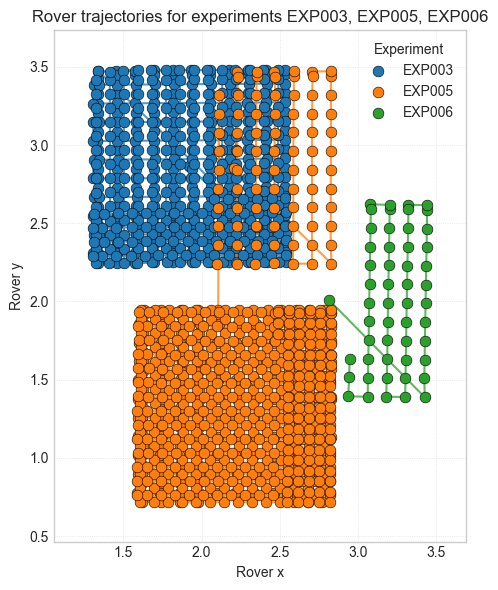

In [38]:
# print(f'Combined heatmaps and trajectory for {plottable_experiment_ids}')
# plot_phase_heatmap(ds, plottable_experiment_ids)
# plt.show()
# plot_amplitude_heatmap(ds, plottable_experiment_ids)
# plt.show()
plot_trajectory(ds, plottable_experiment_ids)
plt.show()

# Optional separate plots:
# for selected_experiment_id in plottable_experiment_ids:
#     print(f'Heatmaps and trajectory for {selected_experiment_id}')
#     plot_phase_heatmap(ds, selected_experiment_id)
#     plt.show()
#     plot_amplitude_heatmap(ds, selected_experiment_id)
#     plt.show()
#     plot_trajectory(ds, selected_experiment_id)
#     plt.show()


Combined phase rover frame for ['EXP003', 'EXP005', 'EXP006']


C:\Users\Calle\AppData\Local\Temp\ipykernel_24880\4105060505.py:990: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


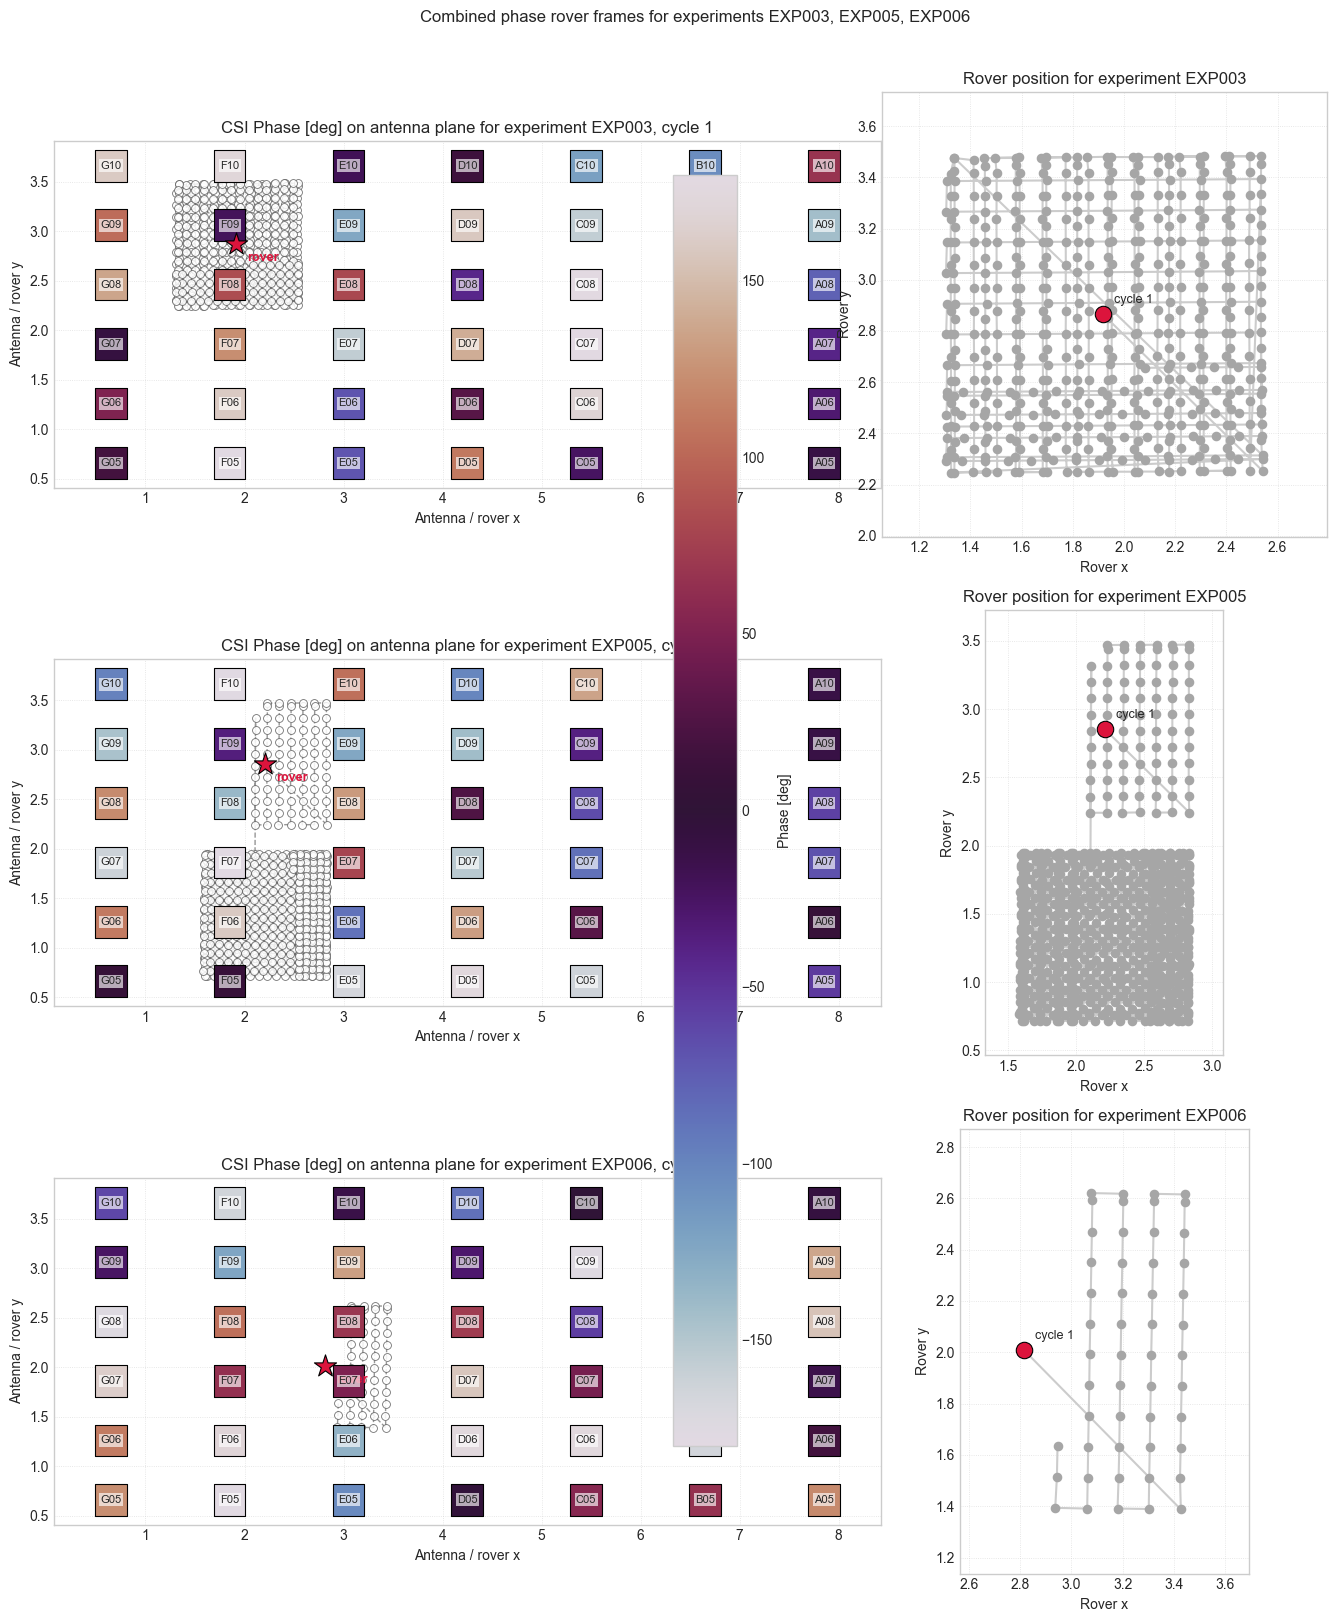

In [39]:
print(f'Combined phase rover frame for {plottable_experiment_ids}')
plot_phase_rover_frame(ds, plottable_experiment_ids, first_available_cycle_ids)
plt.show()

# Optional separate frames:
# for selected_experiment_id in plottable_experiment_ids:
#     selected_cycle_id = first_available_cycle_ids[selected_experiment_id]
#     print(f'Selected experiment: {selected_experiment_id}')
#     print(f'Selected cycle: {selected_cycle_id}')
#     plot_phase_rover_frame(ds, selected_experiment_id, selected_cycle_id)
#     plt.show()


In [40]:
# combined_phase_movie_path = create_phase_rover_movie(
#     ds,
#     plottable_experiment_ids,
#     fps=10,
#     file_format='mp4',
# )
# print(f'Saved combined movie: {combined_phase_movie_path}')
#
# Optional separate movies:
# for selected_experiment_id in plottable_experiment_ids:
#     movie_path = create_phase_rover_movie(
#         ds,
#         selected_experiment_id,
#         fps=10,
#         file_format='mp4',
#     )
#     print(f'Saved movie for {selected_experiment_id}: {movie_path}')


Combined power rover frame for ['EXP003', 'EXP005', 'EXP006']


C:\Users\Calle\AppData\Local\Temp\ipykernel_24880\4105060505.py:1077: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


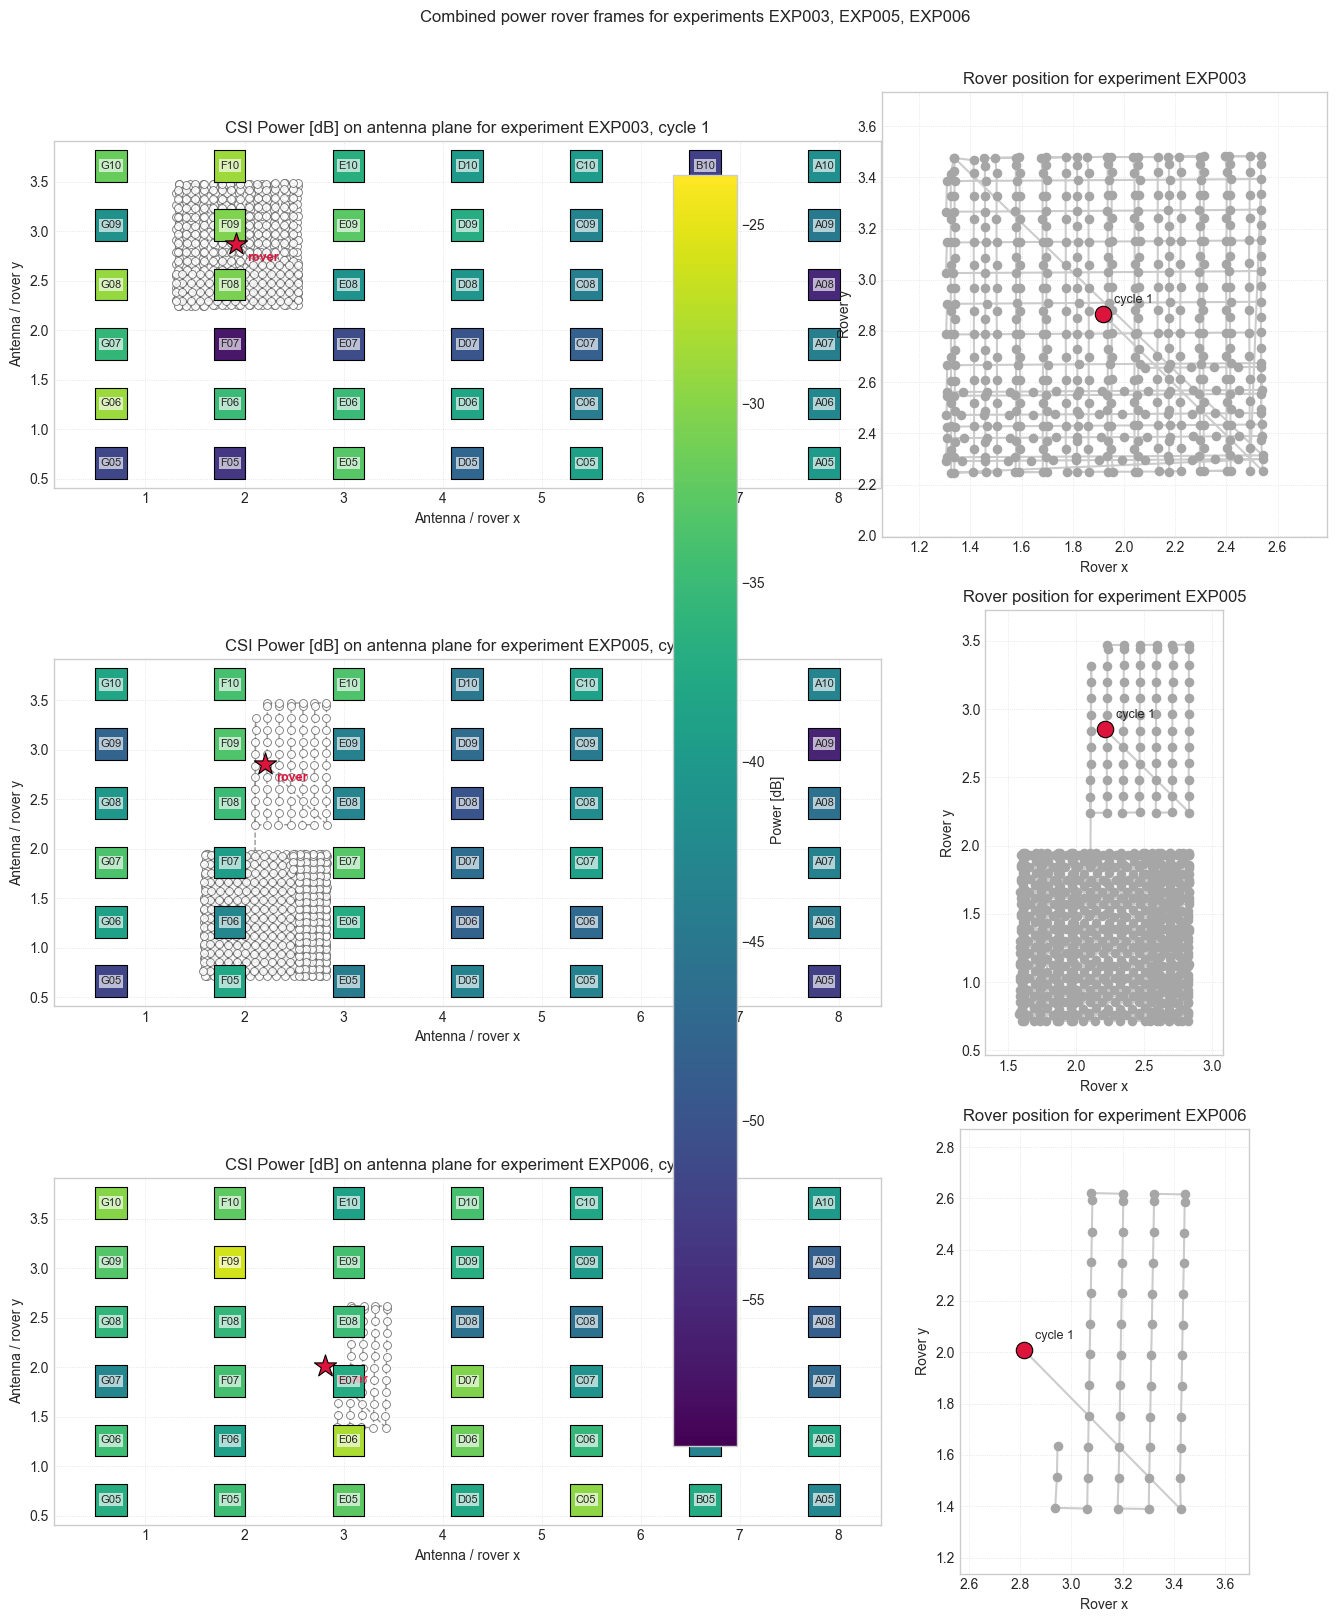

In [41]:
print(f'Combined power rover frame for {plottable_experiment_ids}')
plot_power_rover_frame(ds, plottable_experiment_ids, first_available_cycle_ids)
plt.show()

# Optional separate frames:
# for selected_experiment_id in plottable_experiment_ids:
#     selected_cycle_id = first_available_cycle_ids[selected_experiment_id]
#     print(f'Power frame for experiment: {selected_experiment_id}')
#     print(f'Selected cycle: {selected_cycle_id}')
#     plot_power_rover_frame(ds, selected_experiment_id, selected_cycle_id)
#     plt.show()


In [42]:
# combined_power_movie_path = create_power_rover_movie(
#     ds,
#     plottable_experiment_ids,
#     fps=10,
#     file_format='mp4',
# )
# print(f'Saved combined power movie: {combined_power_movie_path}')
#
# Optional separate movies:
# for selected_experiment_id in plottable_experiment_ids:
#     power_movie_path = create_power_rover_movie(
#         ds,
#         selected_experiment_id,
#         fps=10,
#         file_format='mp4',
#     )
#     print(f'Saved power movie for {selected_experiment_id}: {power_movie_path}')
